# FoldForge - M2-M5: the differentiable design pipeline

M0-M1 built geometry and a 3D fold simulator. M2-M5 turn folding into a *design*
tool, all in pure numpy (no deep-learning framework):

- **M2** differentiable kinematics - gradients through a fold,
- **M3** inverse design - gradient descent from a target shape to a fold,
- **M4** a generative model that proposes folds, trained with the simulator in
  the loop,
- **M5** origami metamaterials - the Miura's auxetic mechanics, and inverse
  design of them.


## M2 - Differentiable kinematics

A *fold chain* (a strip of rigid panels) folds into an arch. Its shape is a
smooth function of the fold angles, so we can get the gradient of, say, the apex
height with respect to each fold angle - and check it against finite
differences.

apex height = 3.573
d(apex)/d(angle3): analytic 0.433095  vs finite-diff 0.433095


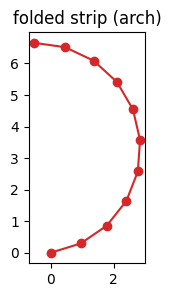

In [1]:
import numpy as np, matplotlib.pyplot as plt
from foldforge.diff import fold_chain, apex_height, apex_height_grad

angles = np.full(10, 0.3)                      # uniform fold -> arch
res = fold_chain(angles)
g = apex_height_grad(angles)
# finite-difference check on one angle
eps = 1e-6; a = angles.copy(); a[3]+=eps; a2=angles.copy(); a2[3]-=eps
fd = (apex_height(a)-apex_height(a2))/(2*eps)
print(f"apex height = {apex_height(angles):.3f}")
print(f"d(apex)/d(angle3): analytic {g[3]:.6f}  vs finite-diff {fd:.6f}")
plt.figure(figsize=(6,3)); plt.plot(res.spine[:,0],res.spine[:,1],'-o',color='#d62728')
plt.gca().set_aspect('equal'); plt.title('folded strip (arch)'); plt.show()

## M3 - Inverse design

Given a target curve, descend the gradient to recover the fold angles that
produce it. Here: a flat strip morphed into an arch and an S-wave.

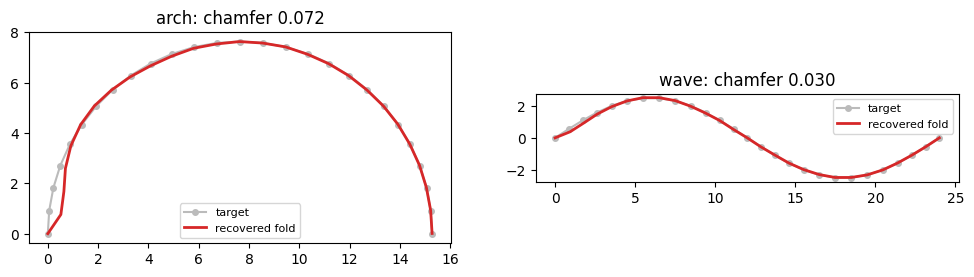

In [2]:
from foldforge.design import fit_chain, target_arch, target_wave
fig,ax=plt.subplots(1,2,figsize=(12,3.5))
for a,(name,tgt) in zip(ax,[('arch',target_arch(26)),('wave',target_wave(26))]):
    r=fit_chain(tgt,iters=700,lr=0.05)
    a.plot(tgt[:,0],tgt[:,1],'o-',color='#bbb',ms=4,label='target')
    a.plot(r.spine[:,0],r.spine[:,1],'-',color='#d62728',lw=2,label='recovered fold')
    a.set_aspect('equal'); a.legend(fontsize=8); a.set_title(f'{name}: chamfer {r.chamfer:.3f}')
plt.show()

## M4 - Generative model (simulator in the loop)

A small network learns to *propose* a fold for any target in one shot, trained
by folding its proposals and backpropagating the shape error. It beats random
folds by a wide margin on held-out targets. (Short training run here.)

held-out reconstruction loss:  net 2.462  vs random 50.568  (21x better)


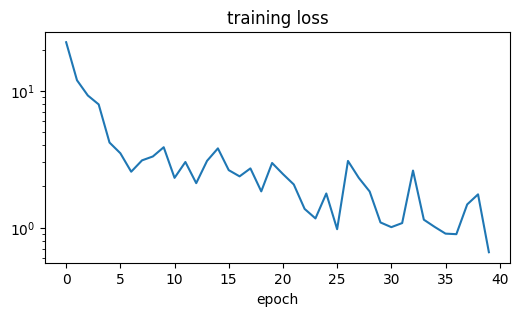

In [3]:
from foldforge.generative import FoldGenerator, make_dataset, batch_recon_grad
n=14; rng=np.random.default_rng(0)
Xtr=make_dataset(1200,n,1.0,rng); Xte=make_dataset(200,n,1.0,rng)
gen=FoldGenerator(n=n,seg=1.0,hidden=64); hist=gen.train(Xtr,epochs=40)
y=gen._forward(np.concatenate([Xte,np.zeros((len(Xte),gen.noise_dim))],1))[0]
Lnet,_=batch_recon_grad(y,Xte.reshape(len(Xte),-1,2),1.0)
yr=rng.uniform(-0.35,0.35,(len(Xte),n)); Lrand,_=batch_recon_grad(yr,Xte.reshape(len(Xte),-1,2),1.0)
print(f"held-out reconstruction loss:  net {Lnet:.3f}  vs random {Lrand:.3f}  ({Lrand/Lnet:.0f}x better)")
plt.figure(figsize=(6,3)); plt.plot(hist); plt.yscale('log'); plt.xlabel('epoch'); plt.title('training loss'); plt.show()

## M5 - Origami metamaterials

The Miura-ori is auxetic: a **negative** in-plane Poisson's ratio that depends on
fold state and sector angle. We compute it from the cell kinematics and inverse-
design the sector angle to a target response. (Kinematic model - trends, not a
validated stress analysis.)

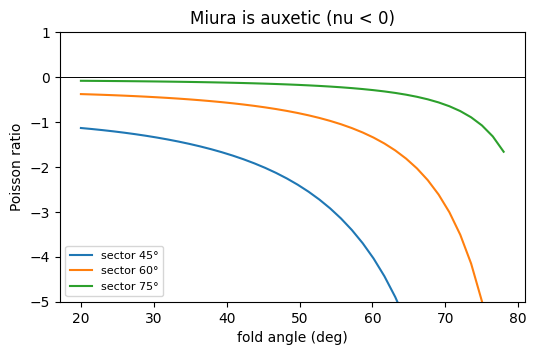

inverse design: target sector 50.0° -> recovered 50.0°


In [4]:
from foldforge.materials import poisson_curve, fit_sector_angle
ths=np.radians(np.linspace(20,78,40)); thd=np.degrees(ths)
plt.figure(figsize=(6,3.5))
for al in (45,60,75): plt.plot(thd,poisson_curve(np.radians(al),ths),label=f'sector {al}°')
plt.axhline(0,color='k',lw=.7); plt.ylim(-5,1); plt.xlabel('fold angle (deg)')
plt.ylabel('Poisson ratio'); plt.title('Miura is auxetic (nu < 0)'); plt.legend(fontsize=8); plt.show()
true=np.radians(50); tgt=poisson_curve(true,ths)
print(f"inverse design: target sector 50.0° -> recovered {np.degrees(fit_sector_angle(ths,tgt)):.1f}°")

## Recap

From a flat sheet we can now: fold it (M1), differentiate the fold (M2), invert
it to hit a target (M3), train a model to propose folds (M4), and read off and
design its mechanics (M5) - and watch any of it in the browser studio (M6).

Everything is pure numpy with gradients verified against finite differences.